In [371]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [372]:
df=pd.read_csv('placement.csv')

In [373]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [375]:
df.isna().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [376]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [377]:
df.shape

(10000, 10)

In [378]:
df = df.drop("College_ID", axis=1)

In [379]:
print(df['Placement'].value_counts())
print(df['Placement'].value_counts(normalize=True))

Placement
No     8341
Yes    1659
Name: count, dtype: int64
Placement
No     0.8341
Yes    0.1659
Name: proportion, dtype: float64


In [380]:
df['Placement'] = df['Placement'].map({'Yes': 1, 'No': 0})

In [381]:
print(df["Placement"].value_counts())

Placement
0    8341
1    1659
Name: count, dtype: int64


<Axes: xlabel='CGPA', ylabel='Count'>

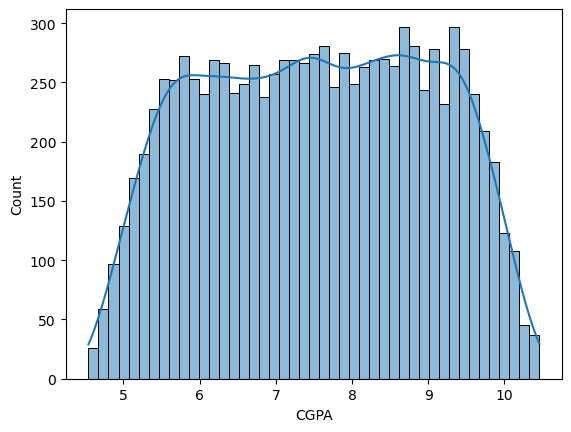

In [382]:
sns.histplot(df['CGPA'],bins=45,kde=True)

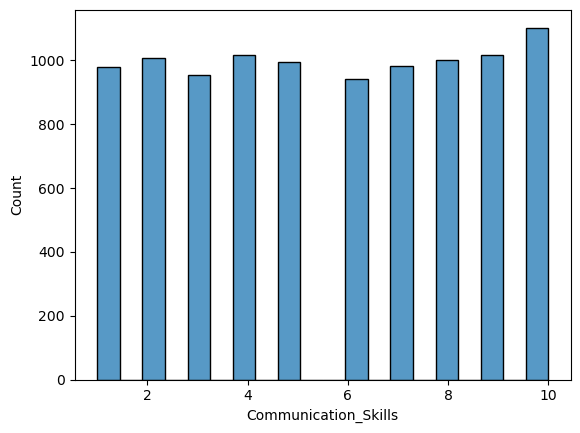

In [383]:
sns.histplot(df["Communication_Skills"])
plt.show()

<Axes: xlabel='Academic_Performance', ylabel='Placement'>

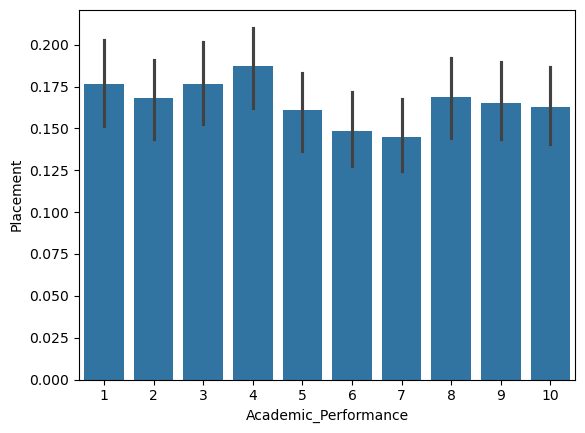

In [384]:
sns.barplot(x=df['Academic_Performance'],y=df['Placement'])

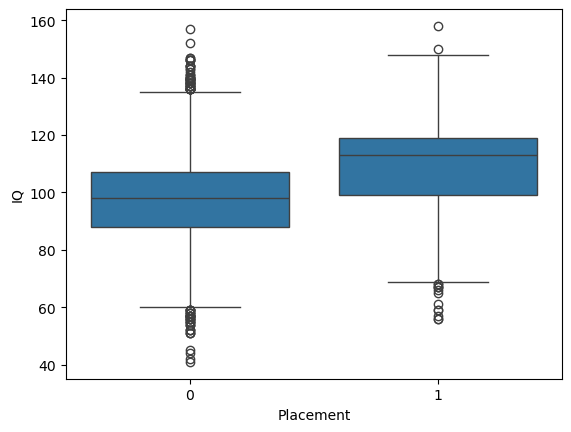

In [385]:
sns.boxplot(x='Placement', y='IQ', data=df)
plt.show()

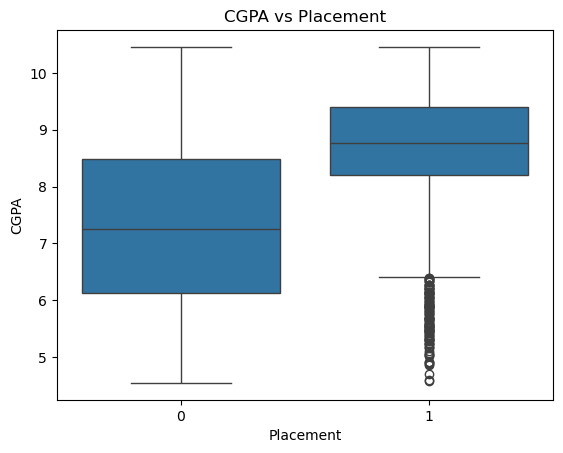

In [386]:
sns.boxplot(
    x="Placement",
    y="CGPA",
    data=df
)

plt.title("CGPA vs Placement")
plt.show()

<Axes: >

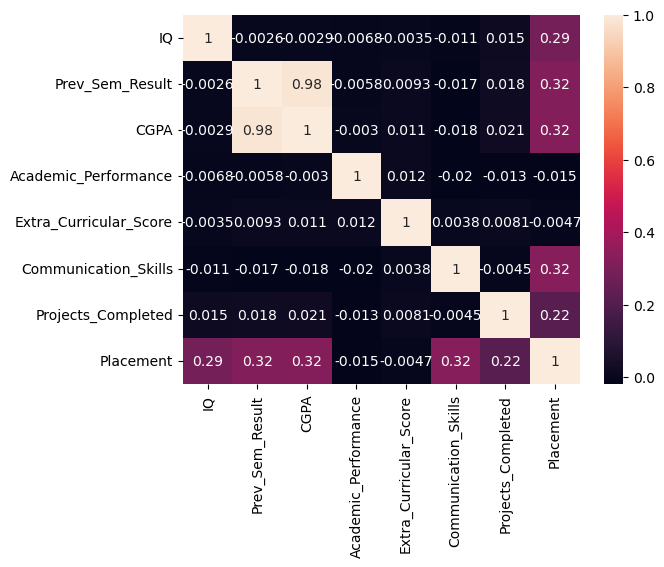

In [387]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [388]:
df = pd.get_dummies(
    df,
    columns=['Internship_Experience'],
    dtype=int
)


In [389]:
x=df.drop('Placement',axis=1)
y=df['Placement']


In [390]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [391]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [392]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [393]:
y_pred=model.predict(X_test)
count=0
for i in y_pred:
    if i==1:
        count+=1
count

251

In [394]:
y_test.value_counts()

Placement
0    1668
1     332
Name: count, dtype: int64

In [395]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9035

Confusion Matrix:
[[1612   56]
 [ 137  195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1668
           1       0.78      0.59      0.67       332

    accuracy                           0.90      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



In [396]:
y_prob = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9450734593048451


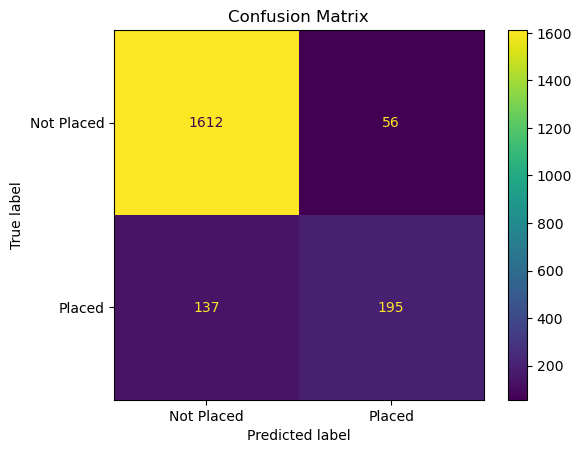

In [397]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix")
plt.show()

In [398]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:

    y_threshold = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_threshold,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.50 | Precision: 0.78 | Recall: 0.59 | F1: 0.67
Threshold: 0.55 | Precision: 0.80 | Recall: 0.53 | F1: 0.64
Threshold: 0.60 | Precision: 0.81 | Recall: 0.51 | F1: 0.62
Threshold: 0.65 | Precision: 0.83 | Recall: 0.45 | F1: 0.58
Threshold: 0.70 | Precision: 0.88 | Recall: 0.41 | F1: 0.56
Threshold: 0.75 | Precision: 0.90 | Recall: 0.37 | F1: 0.52
Threshold: 0.80 | Precision: 0.91 | Recall: 0.32 | F1: 0.47


In [399]:

import joblib

joblib.dump(model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x.columns.tolist(), "features.pkl")
joblib.dump(threshold, "threshold.pkl")

['threshold.pkl']